### ***Mount and Locate***

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import os

possible_paths = [
    "/content/drive/MyDrive/Generalizable-DDA-RL",
    "/content/drive/MyDrive/generalizable-dda-rl",
    "/content/drive/MyDrive/GADDA-RL",
]

PROJECT_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        PROJECT_PATH = path
        break

if PROJECT_PATH is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_PATH manually."
    )

print("Project:", PROJECT_PATH)

Project: /content/drive/MyDrive/Generalizable-DDA-RL


In [3]:
import sys

os.chdir(PROJECT_PATH)

if PROJECT_PATH not in sys.path:
    sys.path.append(PROJECT_PATH)

print("Working directory:")
print(os.getcwd())

Working directory:
/content/drive/MyDrive/Generalizable-DDA-RL


### ***Install and Imports***

In [4]:
!pip install -q plotly
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_rel

import plotly.express as px
import plotly.graph_objects as go

### ***Final Output Folders***

In [5]:
FINAL_RESULTS_DIR = "results/final_analysis"
FINAL_FIGURES_DIR = "figures/final_analysis"
FINAL_TABLES_DIR = "results/final_analysis/tables"
FINAL_INTERACTIVE_DIR = "results/final_analysis/interactive"

for folder in [
    FINAL_RESULTS_DIR,
    FINAL_FIGURES_DIR,
    FINAL_TABLES_DIR,
    FINAL_INTERACTIVE_DIR
]:
    os.makedirs(folder, exist_ok=True)

print("Final analysis directories ready.")

Final analysis directories ready.


### ***Load Generalization Results***

In [6]:
GENERALIZATION_PATH = (
    "results/generalization/tables/"
    "generalization_raw_results.csv"
)

generalization_df = pd.read_csv(GENERALIZATION_PATH)

print("Generalization shape:", generalization_df.shape)
print(generalization_df.columns.tolist())

Generalization shape: (250, 11)
['Method', 'Total Reward', 'Final Win Rate', 'Mean Rolling Win Rate', 'Win Rate Error', 'Mean Difficulty', 'Difficulty Std', 'Mean Absolute Difficulty Change', 'Episode Length', 'Player Profile', 'Seed']


### ***Load Uncertainity Ablation Results***

In [7]:
ABLATION_PATH = (
    "results/ablation/"
    "uncertainty_ablation_raw_results.csv"
)

ablation_df = pd.read_csv(ABLATION_PATH)

print("Ablation shape:", ablation_df.shape)
print(ablation_df.columns.tolist())

Ablation shape: (50, 10)
['Method', 'Profile', 'Seed', 'Total Reward', 'Final Rolling Win Rate', 'Mean Win Rate', 'Win Rate Error', 'Difficulty Std', 'Mean Absolute Difficulty Change', 'Episode Length']


### ***Load Robustness Results***

In [8]:
ROBUSTNESS_PATH = (
    "results/robustness/"
    "behavioural_noise_robustness_raw_results.csv"
)

robustness_df = pd.read_csv(ROBUSTNESS_PATH)

print("Robustness shape:", robustness_df.shape)
print(robustness_df.columns.tolist())

Robustness shape: (50, 9)
['Noise Level', 'Seed', 'Total Reward', 'Final Rolling Win Rate', 'Mean Win Rate', 'Win Rate Error', 'Difficulty Std', 'Mean Absolute Difficulty Change', 'Episode Length']


### ***Verify Robustness Data***

In [9]:
assert len(robustness_df) == 50

assert sorted(
    robustness_df["Noise Level"].unique()
) == [0.05, 0.10, 0.15, 0.20, 0.30]

assert robustness_df["Seed"].nunique() == 10

print("✓ Robustness dataset validated")

✓ Robustness dataset validated


### ***Consolidated Experiment Overview***

In [10]:
experiment_overview = pd.DataFrame({
    "Experiment": [
        "Standard Evaluation",
        "Unseen-Profile Generalization",
        "Uncertainty Ablation",
        "Behavioural Noise Robustness"
    ],
    "Purpose": [
        "Compare PPO against static and rule-based DDA",
        "Evaluate performance on held-out player configurations",
        "Measure the contribution of uncertainty information",
        "Test performance across increasing behavioural noise"
    ],
    "Evaluation Runs": [
        40,
        50,
        50,
        50
    ],
    "Primary Metric": [
        "Win Rate Error",
        "Win Rate Error",
        "Win Rate Error",
        "Win Rate Error"
    ]
})

experiment_overview

,Experiment,Purpose,Evaluation Runs,Primary Metric
0,Standard Evaluation,Compare PPO against static and rule-based DDA,40,Win Rate Error
1,Unseen-Profile Generalization,Evaluate performance on held-out player config...,50,Win Rate Error
2,Uncertainty Ablation,Measure the contribution of uncertainty inform...,50,Win Rate Error
3,Behavioural Noise Robustness,Test performance across increasing behavioural...,50,Win Rate Error


### ***Experiment Table***

In [11]:
fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=list(experiment_overview.columns),
                align="left"
            ),
            cells=dict(
                values=[
                    experiment_overview[col]
                    for col in experiment_overview.columns
                ],
                align="left"
            )
        )
    ]
)

fig.update_layout(
    title="GADDA-RL Experimental Evaluation Overview"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/experiment_overview.html"
)

### ***Standard Evaluation Headline Results***

In [12]:
standard_results = pd.DataFrame({
    "Method": [
        "PPO DDA",
        "Static Easy",
        "Static Medium",
        "Static Hard",
        "Rule-Based DDA"
    ],
    "Win Rate Error": [
        0.085484,
        0.230296,
        0.204530,
        0.518323,
        0.133969
    ]
})

standard_results

,Method,Win Rate Error
0,PPO DDA,0.085484
1,Static Easy,0.230296
2,Static Medium,0.204530
3,Static Hard,0.518323
4,Rule-Based DDA,0.133969


### ***Calculate Standard-Evaluation Improvements***

In [13]:
ppo_error = standard_results.loc[
    standard_results["Method"] == "PPO DDA",
    "Win Rate Error"
].iloc[0]

standard_results["Improvement vs PPO (%)"] = np.nan

for i, row in standard_results.iterrows():

    if row["Method"] != "PPO DDA":
        standard_results.loc[i, "Improvement vs PPO (%)"] = (
            (row["Win Rate Error"] - ppo_error)
            / row["Win Rate Error"]
            * 100
        )

standard_results.round(4)

,Method,Win Rate Error,Improvement vs PPO (%)
0,PPO DDA,0.0855,NaN
1,Static Easy,0.2303,62.8808
2,Static Medium,0.2045,58.2047
3,Static Hard,0.5183,83.5076
4,Rule-Based DDA,0.1340,36.1912


### ***Standard Evaluation Figure***

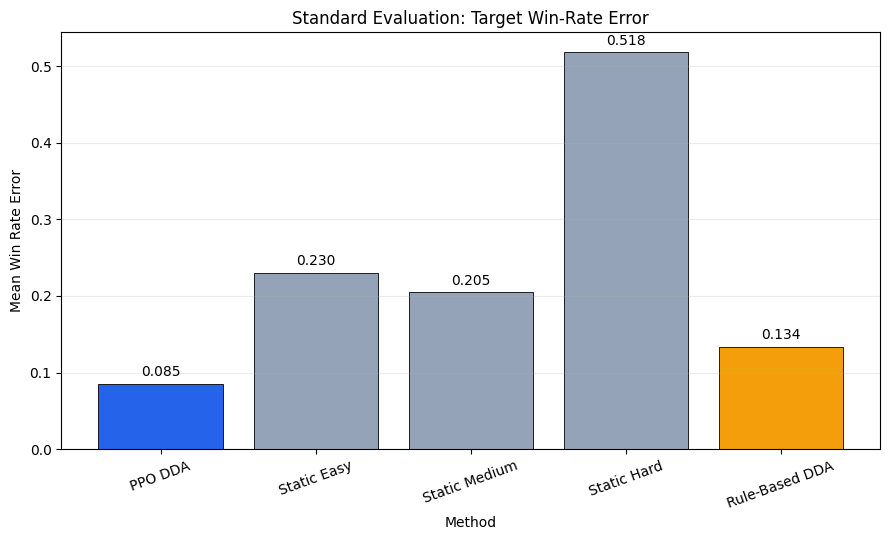

In [14]:
plt.figure(figsize=(9, 5.5))

methods = standard_results["Method"]
errors = standard_results["Win Rate Error"]

colors = [
    "#2563EB",  # PPO
    "#94A3B8",
    "#94A3B8",
    "#94A3B8",
    "#F59E0B"
]

bars = plt.bar(
    methods,
    errors,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.ylabel("Mean Win Rate Error")
plt.xlabel("Method")
plt.title("Standard Evaluation: Target Win-Rate Error")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    f"{FINAL_FIGURES_DIR}/standard_evaluation_win_rate_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Standard Evaluation Chart***

In [15]:
fig = px.bar(
    standard_results,
    x="Method",
    y="Win Rate Error",
    title="Standard Evaluation — Interactive Comparison",
    text="Win Rate Error"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    yaxis_title="Mean Win Rate Error",
    xaxis_title="Method"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/standard_evaluation.html"
)

### ***Generalization Summary***

In [16]:
generalization_summary = (
    generalization_df
    .groupby("Method")
    .agg(
        Mean_Win_Rate_Error=("Win Rate Error", "mean"),
        SD_Win_Rate_Error=("Win Rate Error", "std"),
        Mean_Total_Reward=("Total Reward", "mean"),
        SD_Total_Reward=("Total Reward", "std"),
        Mean_Final_Win_Rate=("Final Win Rate", "mean"),
        SD_Final_Win_Rate=("Final Win Rate", "std")
    )
    .reset_index()
)

generalization_summary.round(4)

,Method,Mean_Win_Rate_Error,SD_Win_Rate_Error,Mean_Total_Reward,SD_Total_Reward,Mean_Final_Win_Rate,SD_Final_Win_Rate
0,PPO DDA,0.0800,0.0417,179.2443,15.2536,0.708,0.1523
1,Rule-Based DDA,0.1708,0.0981,104.3024,44.7730,0.864,0.1481
2,Static Easy,0.2414,0.1331,11.5624,104.7419,0.568,0.3798
3,Static Hard,0.4088,0.2276,-232.4599,264.9005,0.380,0.4417
4,Static Medium,0.3261,0.2111,-129.8802,203.7734,0.450,0.4523


### ***Generalization Figure***

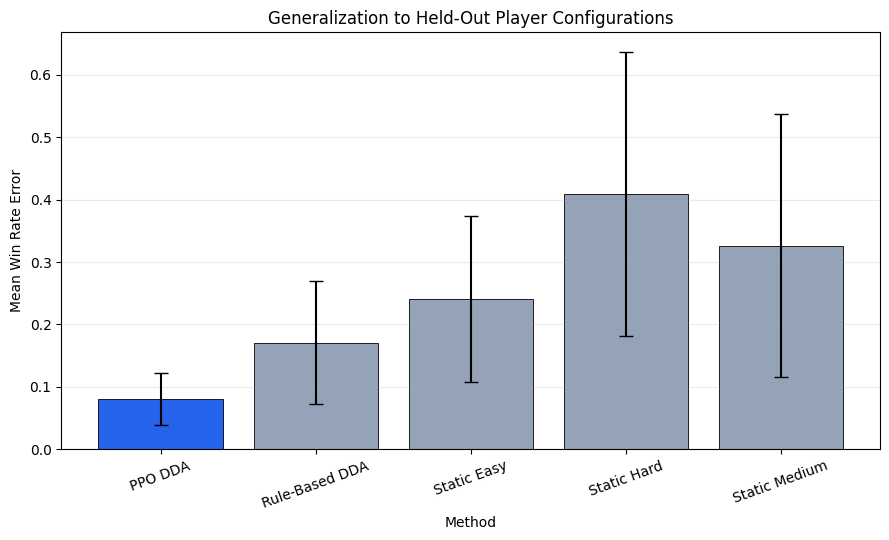

In [17]:
plt.figure(figsize=(9, 5.5))

methods = generalization_summary["Method"]
errors = generalization_summary["Mean_Win_Rate_Error"]
stds = generalization_summary["SD_Win_Rate_Error"]

colors = [
    "#2563EB" if method == "PPO DDA"
    else "#94A3B8"
    for method in methods
]

plt.bar(
    methods,
    errors,
    yerr=stds,
    capsize=5,
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.ylabel("Mean Win Rate Error")
plt.xlabel("Method")
plt.title("Generalization to Held-Out Player Configurations")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    f"{FINAL_FIGURES_DIR}/generalization_win_rate_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Generalization Chart***

In [18]:
fig = px.bar(
    generalization_summary,
    x="Method",
    y="Mean_Win_Rate_Error",
    error_y="SD_Win_Rate_Error",
    title="Generalization — Win Rate Error",
    text="Mean_Win_Rate_Error"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Method",
    yaxis_title="Mean Win Rate Error"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/generalization.html"
)

### ***Profile Wise Generalization***

In [19]:
profile_generalization = (
    generalization_df
    .groupby(["Player Profile", "Method"])
    ["Win Rate Error"]
    .mean()
    .reset_index()
)

profile_generalization.round(4)

,Player Profile,Method,Win Rate Error
0,Unseen Fast Learning,PPO DDA,0.0707
1,Unseen Fast Learning,Rule-Based DDA,0.2375
2,Unseen Fast Learning,Static Easy,0.1601
3,Unseen Fast Learning,Static Hard,0.1710
4,Unseen Fast Learning,Static Medium,0.0206
5,Unseen High Noise,PPO DDA,0.0525
6,Unseen High Noise,Rule-Based DDA,0.1199
7,Unseen High Noise,Static Easy,0.2094
8,Unseen High Noise,Static Hard,0.5965
9,Unseen High Noise,Static Medium,0.4430


### ***Profile Generalization***

In [21]:
fig = px.bar(
    profile_generalization,
    x="Player Profile",
    y="Win Rate Error",
    color="Method",
    barmode="group",
    title="Generalization Across Held-Out Player Profiles",
    text_auto=".3f"
)

fig.update_layout(
    xaxis_title="Held-Out Player Profile",
    yaxis_title="Mean Win Rate Error",
    legend_title="Method"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/profile_generalization.html"
)

### ***Uncertainity Ablation Headline Result***

In [22]:
ablation_headline = pd.DataFrame({
    "Model": [
        "Full PPO",
        "PPO Without Uncertainty"
    ],
    "Mean Win Rate Error": [
        0.080002,
        0.194935
    ]
})

ablation_headline

,Model,Mean Win Rate Error
0,Full PPO,0.080002
1,PPO Without Uncertainty,0.194935


### ***Calculate Uncertainity Contribution***

In [23]:
full_error = 0.080001746
no_uncertainty_error = 0.194935

error_increase = (
    (no_uncertainty_error - full_error)
    / full_error
    * 100
)

error_reduction = (
    (no_uncertainty_error - full_error)
    / no_uncertainty_error
    * 100
)

print(f"Error increase without uncertainty: {error_increase:.2f}%")
print(f"Error reduction with uncertainty: {error_reduction:.2f}%")

Error increase without uncertainty: 143.66%
Error reduction with uncertainty: 58.96%


### ***Ablation Figure***

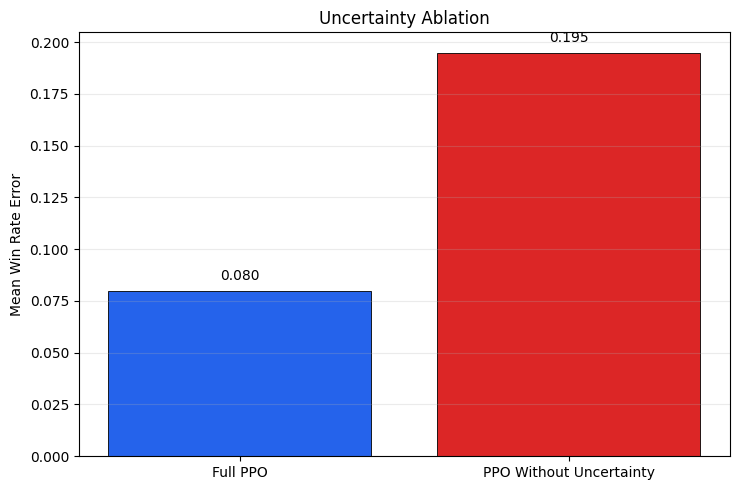

In [24]:
plt.figure(figsize=(7.5, 5))

colors = [
    "#2563EB",
    "#DC2626"
]

bars = plt.bar(
    ablation_headline["Model"],
    ablation_headline["Mean Win Rate Error"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.ylabel("Mean Win Rate Error")
plt.title("Uncertainty Ablation")

plt.grid(axis="y", alpha=0.25)

for bar, value in zip(
    bars,
    ablation_headline["Mean Win Rate Error"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    f"{FINAL_FIGURES_DIR}/uncertainty_ablation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Ablation Chart***

In [25]:
fig = px.bar(
    ablation_headline,
    x="Model",
    y="Mean Win Rate Error",
    title="Uncertainty Ablation — Interactive",
    text="Mean Win Rate Error"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_layout(
    xaxis_title="Model",
    yaxis_title="Mean Win Rate Error"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/uncertainty_ablation.html"
)

### ***Robustness Summary***

In [26]:
robustness_summary_final = (
    robustness_df
    .groupby("Noise Level")
    .agg(
        Win_Rate_Error_Mean=("Win Rate Error", "mean"),
        Win_Rate_Error_SD=("Win Rate Error", "std"),
        Total_Reward_Mean=("Total Reward", "mean"),
        Total_Reward_SD=("Total Reward", "std"),
        Final_Win_Rate_Mean=(
            "Final Rolling Win Rate",
            "mean"
        ),
        Final_Win_Rate_SD=(
            "Final Rolling Win Rate",
            "std"
        )
    )
    .reset_index()
)

robustness_summary_final.round(4)

,Noise Level,Win_Rate_Error_Mean,Win_Rate_Error_SD,Total_Reward_Mean,Total_Reward_SD,Final_Win_Rate_Mean,Final_Win_Rate_SD
0,0.05,0.0256,0.0077,216.8400,6.9139,0.74,0.0699
1,0.10,0.0216,0.0117,210.3706,7.7909,0.73,0.0823
2,0.15,0.0214,0.0106,212.3483,8.4936,0.75,0.0707
3,0.20,0.0178,0.0095,209.5366,8.3865,0.72,0.0789
4,0.30,0.0107,0.0053,204.7160,11.2754,0.72,0.0919


### ***Robustness Figure***

Publication



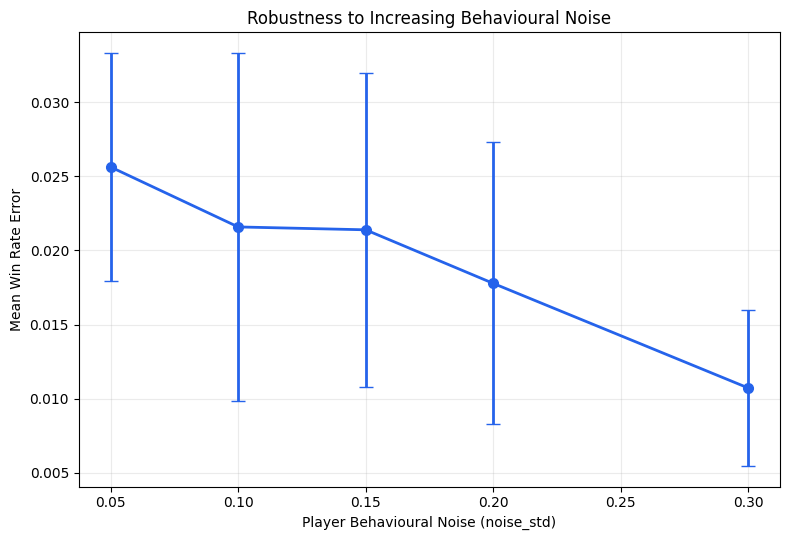

In [27]:
plt.figure(figsize=(8, 5.5))

plt.errorbar(
    robustness_summary_final["Noise Level"],
    robustness_summary_final["Win_Rate_Error_Mean"],
    yerr=robustness_summary_final["Win_Rate_Error_SD"],
    marker="o",
    linewidth=2,
    markersize=7,
    capsize=5,
    color="#2563EB"
)

plt.xlabel("Player Behavioural Noise (noise_std)")
plt.ylabel("Mean Win Rate Error")
plt.title("Robustness to Increasing Behavioural Noise")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    f"{FINAL_FIGURES_DIR}/behavioural_noise_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### ***Robustness Figure***
Interactive

In [28]:
fig = px.line(
    robustness_summary_final,
    x="Noise Level",
    y="Win_Rate_Error_Mean",
    markers=True,
    title="Robustness to Increasing Behavioural Noise",
    error_y="Win_Rate_Error_SD"
)

fig.update_layout(
    xaxis_title="Player Behavioural Noise (noise_std)",
    yaxis_title="Mean Win Rate Error"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/behavioural_noise_robustness.html"
)

### ***Final Evidence Figure***

In [29]:
final_evidence_table = pd.DataFrame({
    "Experiment": [
        "Standard Evaluation",
        "Generalization",
        "Uncertainty Ablation",
        "Behavioural Noise Robustness"
    ],
    "PPO / Full Model Result": [
        0.085484,
        0.080002,
        0.080002,
        0.0107
    ],
    "Comparison / Reference": [
        "Rule-Based DDA: 0.133969",
        "Rule-Based DDA: 0.170797",
        "Without uncertainty: 0.194935",
        "Noise 0.05: 0.0256"
    ],
    "Primary Finding": [
        "Lower target-tracking error than all evaluated baselines",
        "Lower overall error across held-out profiles",
        "Uncertainty information materially improves target tracking",
        "Low error maintained across tested noise levels"
    ]
})

final_evidence_table

,Experiment,PPO / Full Model Result,Comparison / Reference,Primary Finding
0,Standard Evaluation,0.085484,Rule-Based DDA: 0.133969,Lower target-tracking error than all evaluated...
1,Generalization,0.080002,Rule-Based DDA: 0.170797,Lower overall error across held-out profiles
2,Uncertainty Ablation,0.080002,Without uncertainty: 0.194935,Uncertainty information materially improves ta...
3,Behavioural Noise Robustness,0.010700,Noise 0.05: 0.0256,Low error maintained across tested noise levels


In [30]:
fig = go.Figure(
    data=[
        go.Table(
            header=dict(
                values=list(final_evidence_table.columns),
                align="left"
            ),
            cells=dict(
                values=[
                    final_evidence_table[col]
                    for col in final_evidence_table.columns
                ],
                align="left"
            )
        )
    ]
)

fig.update_layout(
    title="GADDA-RL Final Experimental Evidence"
)

fig.show()

fig.write_html(
    f"{FINAL_INTERACTIVE_DIR}/final_evidence_table.html"
)

### ***Save all Final Tables***

In [33]:
experiment_overview.to_csv(
    f"{FINAL_TABLES_DIR}/experiment_overview.csv",
    index=False
)

standard_results.to_csv(
    f"{FINAL_TABLES_DIR}/standard_evaluation.csv",
    index=False
)

generalization_summary.to_csv(
    f"{FINAL_TABLES_DIR}/generalization_summary.csv",
    index=False
)

profile_generalization.to_csv(
    f"{FINAL_TABLES_DIR}/profile_generalization.csv",
    index=False
)

ablation_headline.to_csv(
    f"{FINAL_TABLES_DIR}/uncertainty_ablation.csv",
    index=False
)

robustness_summary_final.to_csv(
    f"{FINAL_TABLES_DIR}/robustness_summary.csv",
    index=False
)

final_evidence_table.to_csv(
    f"{FINAL_TABLES_DIR}/final_evidence_table.csv",
    index=False
)

print("SAVED!")

SAVED!


### ***Final Research Numbers***

In [34]:
print("=" * 60)
print("GADDA-RL FINAL EXPERIMENTAL RESULTS")
print("=" * 60)

print("\n1. STANDARD EVALUATION")
print(f"PPO Win Rate Error: {ppo_error:.4f}")
print("Rule-Based Win Rate Error: 0.1340")
print("Improvement vs Rule-Based: 36.19%")

print("\n2. GENERALIZATION")
print("PPO Mean Win Rate Error: 0.0800")
print("Rule-Based Mean Win Rate Error: 0.1708")
print("Improvement vs Rule-Based: 53.16%")

print("\n3. UNCERTAINTY ABLATION")
print("Full PPO: 0.0800")
print("Without Uncertainty: 0.1949")
print("Error reduction with uncertainty: 58.96%")
print("Paired Cohen's d: 1.564")

print("\n4. BEHAVIOURAL NOISE ROBUSTNESS")
print("Noise 0.05 error: 0.0256")
print("Noise 0.30 error: 0.0107")
print("High-low paired difference: -0.0149")
print("p-value: 0.0001")
print("Paired Cohen's d: -2.128")

print("=" * 60)

GADDA-RL FINAL EXPERIMENTAL RESULTS

1. STANDARD EVALUATION
PPO Win Rate Error: 0.0855
Rule-Based Win Rate Error: 0.1340
Improvement vs Rule-Based: 36.19%

2. GENERALIZATION
PPO Mean Win Rate Error: 0.0800
Rule-Based Mean Win Rate Error: 0.1708
Improvement vs Rule-Based: 53.16%

3. UNCERTAINTY ABLATION
Full PPO: 0.0800
Without Uncertainty: 0.1949
Error reduction with uncertainty: 58.96%
Paired Cohen's d: 1.564

4. BEHAVIOURAL NOISE ROBUSTNESS
Noise 0.05 error: 0.0256
Noise 0.30 error: 0.0107
High-low paired difference: -0.0149
p-value: 0.0001
Paired Cohen's d: -2.128


### ***Final Validation***

In [36]:
checks = {
    "Generalization Runs": len(generalization_df) == 250,
    "Generalization Profiles": generalization_df["Player Profile"].nunique() == 5,
    "Generalization Seeds": generalization_df["Seed"].nunique() == 10,
    "Ablation Runs": len(ablation_df) == 50,
    "Robustness Runs": len(robustness_df) == 50,
    "Robustness Noise Levels": robustness_df["Noise Level"].nunique() == 5
}

for check, passed in checks.items():
    print(f"{'✓' if passed else '✗'} {check}")

assert all(checks.values())

print("\nAll Consolidated Analysis Validation Checks Passed :)")

✓ Generalization Runs
✓ Generalization Profiles
✓ Generalization Seeds
✓ Ablation Runs
✓ Robustness Runs
✓ Robustness Noise Levels

All Consolidated Analysis Validation Checks Passed :)
